# Price Bucket Vector (PBV) Strategy

## Concept

At each LOB snapshot we maintain **5 running vectors** — one per price bucket relative to the midprice — that accumulate weighted order book activity within a minute window.

```
v_mid        ← order imbalance at best bid/ask (around the midpoint)
v_ask_near   ← pressure at best ask (AskPrice_1), closest level above mid
v_ask_far    ← pressure at outer ask levels (AskPrice 2-5), further above mid
v_bid_near   ← pressure at best bid (BidPrice_1), closest level below mid
v_bid_far    ← pressure at outer bid levels (BidPrice 2-5), further below mid
```

Their **cumulative sums within each minute**, plus first and second derivatives, form the trading signal.

**BUY signal logic:** execute when ask-side pressure is decelerating (wall weakening)  
**SELL signal logic:** execute when bid-side pressure is decelerating (support weakening)  
**Fallback:** execute at the last tick of the minute if no signal fires

In [2]:
# ============================================================
# CELL 1: Imports & Data Load
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# NOTE: scale to other stocks by changing this path
STOCK = "INTC"
train_raw = pd.read_csv(f"training_datasets/{STOCK}_5levels_train.csv")

# Parse time; floor to minute for grouping
train_raw["Time_dt"] = pd.to_datetime(train_raw["Time"], format="%H:%M:%S.%f")
train_raw["Minute"]  = train_raw["Time_dt"].dt.floor("min")

print(f"Shape: {train_raw.shape}")
print(f"Columns: {list(train_raw.columns)}")
print(f"Minutes in dataset: {train_raw['Minute'].nunique()}")
train_raw.head(5)

Shape: (430718, 35)
Columns: ['Time', 'BidPrice_5', 'BidPrice_4', 'BidPrice_3', 'BidPrice_2', 'BidPrice_1', 'BidSize_5', 'BidSize_4', 'BidSize_3', 'BidSize_2', 'BidSize_1', 'AskPrice_1', 'AskPrice_2', 'AskPrice_3', 'AskPrice_4', 'AskPrice_5', 'AskSize_1', 'AskSize_2', 'AskSize_3', 'AskSize_4', 'AskSize_5', 'OrderID', 'Size', 'Price', 'Direction_1=Buy_-1=Sell', 'NewLimitOrder_1=Yes_0=No', 'PartialCancel_1=Yes_0=No', 'FullDelete_1=Yes_0=No', 'VisibleExecution_1=Yes_0=No', 'HiddenExecution_1=Yes_0=No', 'TradingHalt_1=Yes_0=No', 'Spread', 'MidPrice', 'Time_dt', 'Minute']
Minutes in dataset: 270


,Time,BidPrice_5,BidPrice_4,BidPrice_3,BidPrice_2,BidPrice_1,BidSize_5,BidSize_4,BidSize_3,BidSize_2,BidSize_1,AskPrice_1,AskPrice_2,AskPrice_3,AskPrice_4,AskPrice_5,AskSize_1,AskSize_2,AskSize_3,AskSize_4,AskSize_5,OrderID,Size,Price,Direction_1=Buy_-1=Sell,NewLimitOrder_1=Yes_0=No,PartialCancel_1=Yes_0=No,FullDelete_1=Yes_0=No,VisibleExecution_1=Yes_0=No,HiddenExecution_1=Yes_0=No,TradingHalt_1=Yes_0=No,Spread,MidPrice,Time_dt,Minute
0,09:30:00.005,27.47,27.48,27.49,27.50,27.51,300,661,200,100,400,27.52,27.53,27.54,27.56,27.57,66,1000,373,100,100,15835012,34,27.52,-1,0,0,0,1,0,0,0.01,27.515,1900-01-01 09:30:00.005,1900-01-01 09:30:00
1,09:30:00.006,27.47,27.48,27.49,27.50,27.51,300,661,200,100,400,27.52,27.53,27.54,27.56,27.57,166,1000,373,100,100,16114545,100,27.52,-1,1,0,0,0,0,0,0.01,27.515,1900-01-01 09:30:00.006,1900-01-01 09:30:00
2,09:30:00.006,27.47,27.48,27.49,27.50,27.51,300,661,200,100,400,27.52,27.53,27.54,27.55,27.56,166,1000,373,100,100,16114695,100,27.55,-1,1,0,0,0,0,0,0.01,27.515,1900-01-01 09:30:00.006,1900-01-01 09:30:00
3,09:30:00.006,27.47,27.48,27.49,27.50,27.51,300,661,200,100,400,27.52,27.53,27.54,27.55,27.56,166,1000,373,100,100,16114707,100,27.58,-1,1,0,0,0,0,0,0.01,27.515,1900-01-01 09:30:00.006,1900-01-01 09:30:00
4,09:30:00.048,27.46,27.47,27.48,27.49,27.51,700,300,661,200,400,27.52,27.53,27.54,27.55,27.56,166,1000,373,100,100,16063194,100,27.50,1,0,0,1,0,0,0,0.01,27.515,1900-01-01 09:30:00.048,1900-01-01 09:30:00


In [3]:
# ============================================================
# CELL 2: Instantaneous Bucket Value Computation
# ============================================================
# Each bucket captures a different type of pressure relative to mid.
# Pressure = size / distance_from_mid  (larger size closer to mid = more pressure)
#
# v_mid      : signed imbalance at the top of book (bid - ask) / (bid + ask)
#              positive  → more bid volume → upward pressure
# v_ask_near : inverse-distance-weighted size at best ask (level 1 above mid)
# v_ask_far  : sum of inverse-distance-weighted sizes at ask levels 2-5
# v_bid_near : inverse-distance-weighted size at best bid (level 1 below mid)
# v_bid_far  : sum of inverse-distance-weighted sizes at bid levels 2-5

EPS = 1e-6  # avoid division by zero

def compute_bucket_row(row):
    mid = row["MidPrice"]

    # --- mid: signed top-of-book imbalance ---
    b1, a1 = row["BidSize_1"], row["AskSize_1"]
    v_mid = (b1 - a1) / (b1 + a1 + EPS)

    # --- ask near: level 1 above mid ---
    dist_ask1 = max(row["AskPrice_1"] - mid, EPS)
    v_ask_near = row["AskSize_1"] / dist_ask1

    # --- ask far: levels 2-5 above mid ---
    v_ask_far = sum(
        row[f"AskSize_{i}"] / max(row[f"AskPrice_{i}"] - mid, EPS)
        for i in range(2, 6)
    )

    # --- bid near: level 1 below mid ---
    dist_bid1 = max(mid - row["BidPrice_1"], EPS)
    v_bid_near = row["BidSize_1"] / dist_bid1

    # --- bid far: levels 2-5 below mid ---
    v_bid_far = sum(
        row[f"BidSize_{i}"] / max(mid - row[f"BidPrice_{i}"], EPS)
        for i in range(2, 6)
    )

    return v_mid, v_ask_near, v_ask_far, v_bid_near, v_bid_far


BUCKET_COLS = ["v_mid", "v_ask_near", "v_ask_far", "v_bid_near", "v_bid_far"]

bucket_vals = train_raw.apply(
    lambda r: compute_bucket_row(r), axis=1, result_type="expand"
)
bucket_vals.columns = BUCKET_COLS

train = pd.concat([train_raw, bucket_vals], axis=1)
print("Bucket columns added.")
train[BUCKET_COLS].describe()

Bucket columns added.


,v_mid,v_ask_near,v_ask_far,v_bid_near,v_bid_far
count,430718.000000,4.307180e+05,4.307180e+05,4.307180e+05,4.307180e+05
mean,0.060414,1.873952e+06,2.090125e+06,2.130362e+06,2.326814e+06
std,0.417892,1.233286e+06,8.027968e+05,1.565505e+06,8.701211e+05
min,-0.999672,2.000000e+02,1.089755e+04,8.000000e+02,2.081333e+04
25%,-0.230297,1.022000e+06,1.789073e+06,1.123900e+06,1.922223e+06
50%,0.071429,1.772600e+06,2.289520e+06,1.900000e+06,2.438714e+06
75%,0.360328,2.592400e+06,2.624281e+06,2.809000e+06,2.851250e+06
max,0.999901,2.045160e+07,8.355926e+06,1.936800e+07,5.779419e+06


In [4]:
# ============================================================
# CELL 3: Cumulative Vectors + Derivatives per Minute
# ============================================================
# Within each minute the vectors accumulate (reset to 0 at each new minute).
# We then compute:
#   _cum   : running sum within the minute (the 'vector state')
#   _d1    : first derivative  of _cum  (velocity  — how fast the state is changing)
#   _d2    : second derivative of _cum  (acceleration — is the velocity itself speeding up?)

for col in BUCKET_COLS:
    # Cumulative sum resets every minute via groupby
    train[f"{col}_cum"] = train.groupby("Minute")[col].cumsum()

    # Derivatives — NaN at minute boundaries is expected and iclaud/ntentional
    train[f"{col}_d1"] = train.groupby("Minute")[f"{col}_cum"].diff()
    train[f"{col}_d2"] = train.groupby("Minute")[f"{col}_d1"].diff()

CUM_COLS = [f"{c}_cum" for c in BUCKET_COLS]
D1_COLS  = [f"{c}_d1"  for c in BUCKET_COLS]
D2_COLS  = [f"{c}_d2"  for c in BUCKET_COLS]

print("Cumulative vectors and derivatives computed.")
print(f"New columns: {CUM_COLS + D1_COLS + D2_COLS}")
train[CUM_COLS + D2_COLS].describe()

Cumulative vectors and derivatives computed.
New columns: ['v_mid_cum', 'v_ask_near_cum', 'v_ask_far_cum', 'v_bid_near_cum', 'v_bid_far_cum', 'v_mid_d1', 'v_ask_near_d1', 'v_ask_far_d1', 'v_bid_near_d1', 'v_bid_far_d1', 'v_mid_d2', 'v_ask_near_d2', 'v_ask_far_d2', 'v_bid_near_d2', 'v_bid_far_d2']


,v_mid_cum,v_ask_near_cum,v_ask_far_cum,v_bid_near_cum,v_bid_far_cum,v_mid_d2,v_ask_near_d2,v_ask_far_d2,v_bid_near_d2,v_bid_far_d2
count,430718.000000,4.307180e+05,4.307180e+05,4.307180e+05,4.307180e+05,430178.000000,4.301780e+05,4.301780e+05,4.301780e+05,4.301780e+05
mean,93.161542,1.865218e+09,2.128710e+09,2.119859e+09,2.371851e+09,-0.000003,6.464766e+00,4.657782e+00,2.956916e+00,5.990576e+00
std,419.053136,1.828013e+09,1.905631e+09,2.016406e+09,2.099622e+09,0.079535,1.242922e+05,4.072718e+04,1.509055e+05,4.649842e+04
min,-897.996244,1.000000e+04,8.562707e+04,5.000000e+04,4.021905e+04,-1.680945,-1.434040e+07,-4.780133e+06,-1.301780e+07,-4.552843e+06
25%,-100.041792,5.806875e+08,7.683116e+08,7.116834e+08,8.688073e+08,-0.005064,-1.192093e-07,-5.960464e-08,-2.384186e-07,-1.192093e-07
50%,16.615504,1.322646e+09,1.654617e+09,1.610815e+09,1.835674e+09,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,180.716160,2.561163e+09,2.980707e+09,2.889130e+09,3.316976e+09,0.004578,2.384186e-07,5.960464e-08,2.384186e-07,1.192093e-07
max,2443.971650,1.257509e+10,1.613541e+10,1.543145e+10,1.743328e+10,1.850288,1.434040e+07,6.304246e+06,1.301780e+07,4.785652e+06


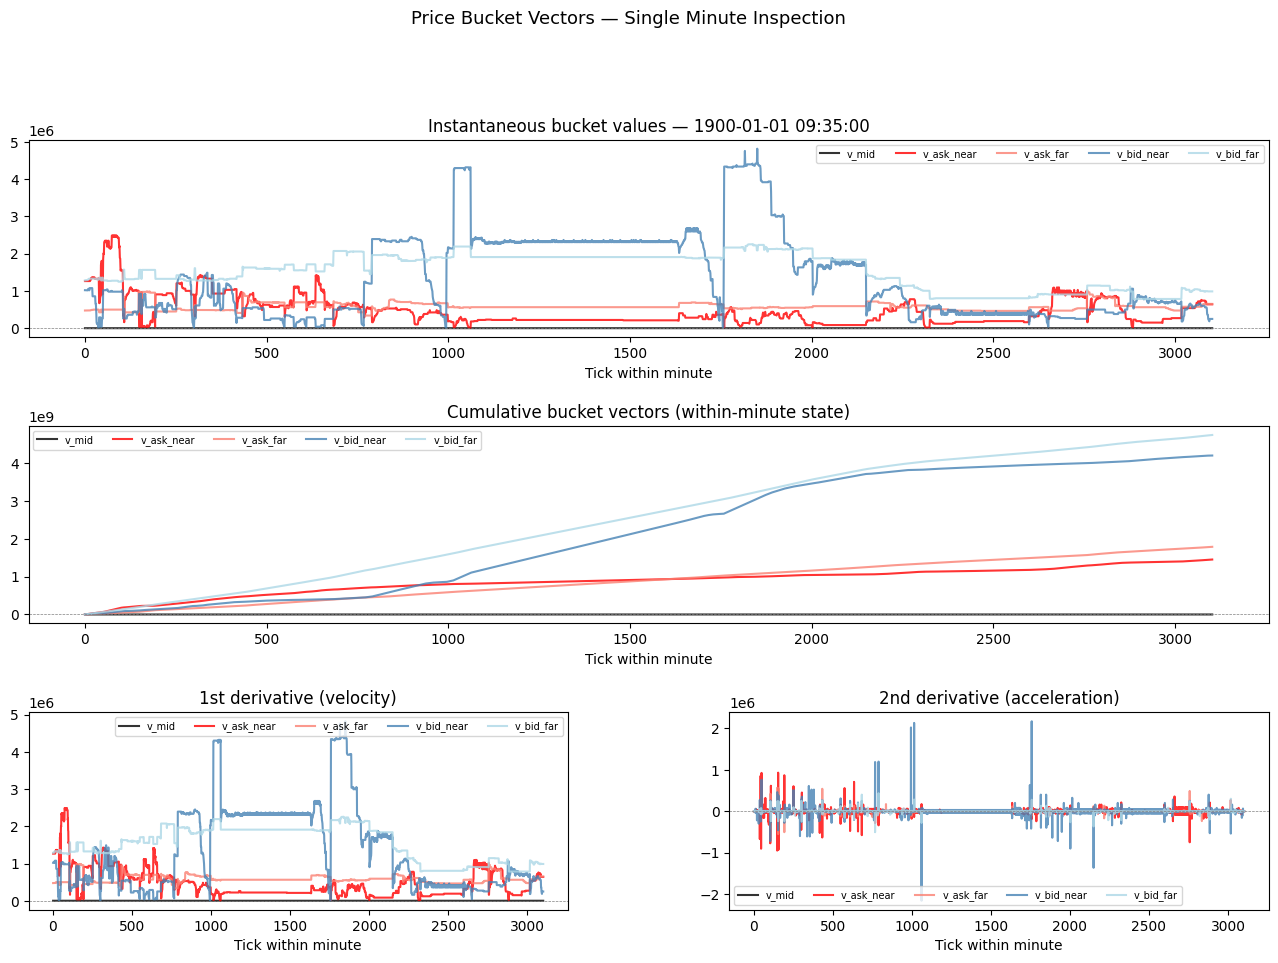

In [5]:
# ============================================================
# CELL 4: Visualise Bucket Vectors for a Sample Minute
# ============================================================
# Pick an arbitrary minute to inspect the raw vectors, cumulative state,
# and their second derivatives side by side.

SAMPLE_MINUTE = train["Minute"].unique()[5]  # change index to explore others
sample = train[train["Minute"] == SAMPLE_MINUTE].reset_index(drop=True)

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

ax_raw  = fig.add_subplot(gs[0, :])
ax_cum  = fig.add_subplot(gs[1, :])
ax_d1   = fig.add_subplot(gs[2, 0])
ax_d2   = fig.add_subplot(gs[2, 1])

colors = ["black", "red", "salmon", "steelblue", "lightblue"]

for col, c in zip(BUCKET_COLS, colors):
    ax_raw.plot(sample[col].values, label=col, color=c, alpha=0.8)
    ax_cum.plot(sample[f"{col}_cum"].values, label=col, color=c, alpha=0.8)
    ax_d1.plot(sample[f"{col}_d1"].values, label=col, color=c, alpha=0.8)
    ax_d2.plot(sample[f"{col}_d2"].values, label=col, color=c, alpha=0.8)

ax_raw.set_title(f"Instantaneous bucket values — {SAMPLE_MINUTE}")
ax_cum.set_title("Cumulative bucket vectors (within-minute state)")
ax_d1.set_title("1st derivative (velocity)")
ax_d2.set_title("2nd derivative (acceleration)")

for ax in [ax_raw, ax_cum, ax_d1, ax_d2]:
    ax.legend(fontsize=7, ncol=5)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.set_xlabel("Tick within minute")

plt.suptitle("Price Bucket Vectors — Single Minute Inspection", fontsize=13, y=1.01)
plt.show()

In [6]:
# ============================================================
# CELL 5: Signal Definition
# ============================================================
# BUY signal: execute when the ask wall is weakening AND bid imbalance tilts up.
#   - v_ask_near_d2 < 0  → near ask pressure is decelerating (wall softening)
#   - v_mid_cum    > 0   → cumulative imbalance favours the bid side
#
# SELL signal: mirror logic.
#   - v_bid_near_d2 < 0  → near bid pressure is decelerating (support weakening)
#   - v_mid_cum    < 0   → cumulative imbalance favours the ask side
#
# FALLBACK: if no signal has fired by FALLBACK_SECONDS, execute at the next tick.

FALLBACK_SECONDS = 50   # execute in last 10s of each minute if no signal
SIDE = "BUY"            # toggle to "SELL" for the sell algorithm

def within_minute_seconds(row):
    """Seconds elapsed since the start of this minute."""
    return (row["Time_dt"] - row["Minute"]).total_seconds()


def buy_signal(row):
    elapsed = within_minute_seconds(row)
    if elapsed >= FALLBACK_SECONDS:
        return True
    # Skip the first 2 ticks — derivatives not meaningful yet (NaN)
    if pd.isna(row["v_ask_near_d2"]) or pd.isna(row["v_mid_cum"]):
        return False
    ask_weakening     = row["v_ask_near_d2"] < 0
    imbalance_up      = row["v_mid_cum"]      > 0
    return bool(ask_weakening and imbalance_up)


def sell_signal(row):
    elapsed = within_minute_seconds(row)
    if elapsed >= FALLBACK_SECONDS:
        return True
    if pd.isna(row["v_bid_near_d2"]) or pd.isna(row["v_mid_cum"]):
        return False
    bid_weakening     = row["v_bid_near_d2"] < 0
    imbalance_down    = row["v_mid_cum"]      < 0
    return bool(bid_weakening and imbalance_down)


SIGNAL_FN      = buy_signal  if SIDE == "BUY"  else sell_signal
EXEC_PRICE_COL = "AskPrice_1" if SIDE == "BUY" else "BidPrice_1"

print(f"Side: {SIDE} | Execution price column: {EXEC_PRICE_COL}")
print(f"Fallback fires after {FALLBACK_SECONDS}s within each minute")

Side: BUY | Execution price column: AskPrice_1
Fallback fires after 50s within each minute


In [7]:
# ============================================================
# CELL 6: Simulate PBV Execution vs TWAP Benchmark
# ============================================================
# TWAP benchmark: first tick of each minute (same as standard TWAP).
# PBV strategy:  first tick where the signal fires.

results = []

for minute, grp in train.groupby("Minute"):
    grp = grp.reset_index(drop=True)

    # TWAP reference: first tick of the minute
    twap_price = grp.iloc[0][EXEC_PRICE_COL]

    # PBV: first row where signal fires
    grp["signal"] = grp.apply(SIGNAL_FN, axis=1)
    fired_rows = grp[grp["signal"]]

    if fired_rows.empty:
        # No signal and fallback didn't trigger — execute at last tick
        fired_row = grp.iloc[-1]
        fallback  = True
    else:
        fired_row = fired_rows.iloc[0]
        fallback  = within_minute_seconds(fired_row) >= FALLBACK_SECONDS

    pbv_price   = fired_row[EXEC_PRICE_COL]
    exec_second = within_minute_seconds(fired_row)

    # For BUY: improvement = lower price is better  → twap - pbv
    # For SELL: improvement = higher price is better → pbv - twap
    improvement = (twap_price - pbv_price) if SIDE == "BUY" else (pbv_price - twap_price)

    results.append({
        "Minute"      : minute,
        "TWAP_price"  : twap_price,
        "PBV_price"   : pbv_price,
        "improvement" : improvement,
        "exec_second" : exec_second,
        "fallback"    : fallback,
        "n_ticks"     : len(grp),
    })

results_df = pd.DataFrame(results)

print("=" * 55)
print(f"  PBV Strategy — {STOCK} — {SIDE}")
print("=" * 55)
print(f"  Total minutes simulated : {len(results_df)}")
print(f"  Fallback executions     : {results_df['fallback'].sum()} "
      f"({100*results_df['fallback'].mean():.1f}%)")
print(f"  Mean improvement vs TWAP: {results_df['improvement'].mean():.5f}")
print(f"  Median improvement      : {results_df['improvement'].median():.5f}")
print(f"  % minutes beating TWAP  : {100*(results_df['improvement'] > 0).mean():.1f}%")
print(f"  Mean exec second        : {results_df['exec_second'].mean():.1f}s")
print()
results_df.describe()

  PBV Strategy — INTC — BUY
  Total minutes simulated : 270
  Fallback executions     : 57 (21.1%)
  Mean improvement vs TWAP: 0.00237
  Median improvement      : 0.00000
  % minutes beating TWAP  : 17.0%
  Mean exec second        : 15.4s



,Minute,TWAP_price,PBV_price,improvement,exec_second,n_ticks
count,270,270.000000,270.000000,270.000000,270.000000,270.000000
mean,1900-01-01 11:44:30,27.160778,27.158407,0.002370,15.405352,1595.251852
min,1900-01-01 09:30:00,26.800000,26.800000,-0.020000,0.005000,156.000000
25%,1900-01-01 10:37:15,26.952500,26.950000,0.000000,0.503250,845.500000
50%,1900-01-01 11:44:30,27.180000,27.180000,0.000000,2.563000,1341.000000
75%,1900-01-01 12:51:45,27.340000,27.337500,0.000000,29.915000,2026.500000
max,1900-01-01 13:59:00,27.580000,27.580000,0.040000,52.065000,12825.000000
std,NaN,0.200181,0.199786,0.008244,20.247258,1235.459024


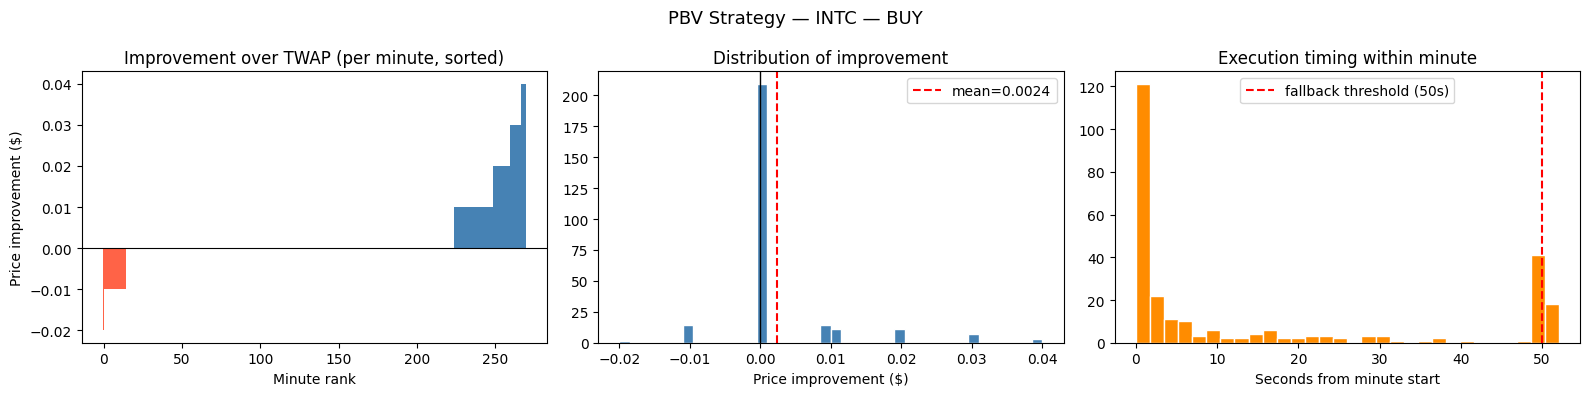

In [8]:
# ============================================================
# CELL 7: Results Visualisation
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Improvement per minute (sorted)
axes[0].bar(
    range(len(results_df)),
    results_df["improvement"].sort_values().values,
    color=["steelblue" if v >= 0 else "tomato"
           for v in results_df["improvement"].sort_values().values],
    width=1.0, edgecolor="none"
)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Improvement over TWAP (per minute, sorted)")
axes[0].set_xlabel("Minute rank")
axes[0].set_ylabel("Price improvement ($)")

# 2. Histogram of improvement
axes[1].hist(results_df["improvement"], bins=40, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].axvline(results_df["improvement"].mean(), color="red",
                linewidth=1.5, linestyle="--", label=f"mean={results_df['improvement'].mean():.4f}")
axes[1].set_title("Distribution of improvement")
axes[1].set_xlabel("Price improvement ($)")
axes[1].legend()

# 3. Execution timing
axes[2].hist(results_df["exec_second"], bins=30, color="darkorange", edgecolor="white")
axes[2].axvline(FALLBACK_SECONDS, color="red", linewidth=1.5,
                linestyle="--", label=f"fallback threshold ({FALLBACK_SECONDS}s)")
axes[2].set_title("Execution timing within minute")
axes[2].set_xlabel("Seconds from minute start")
axes[2].legend()

plt.suptitle(f"PBV Strategy — {STOCK} — {SIDE}", fontsize=13)
plt.tight_layout()
plt.show()

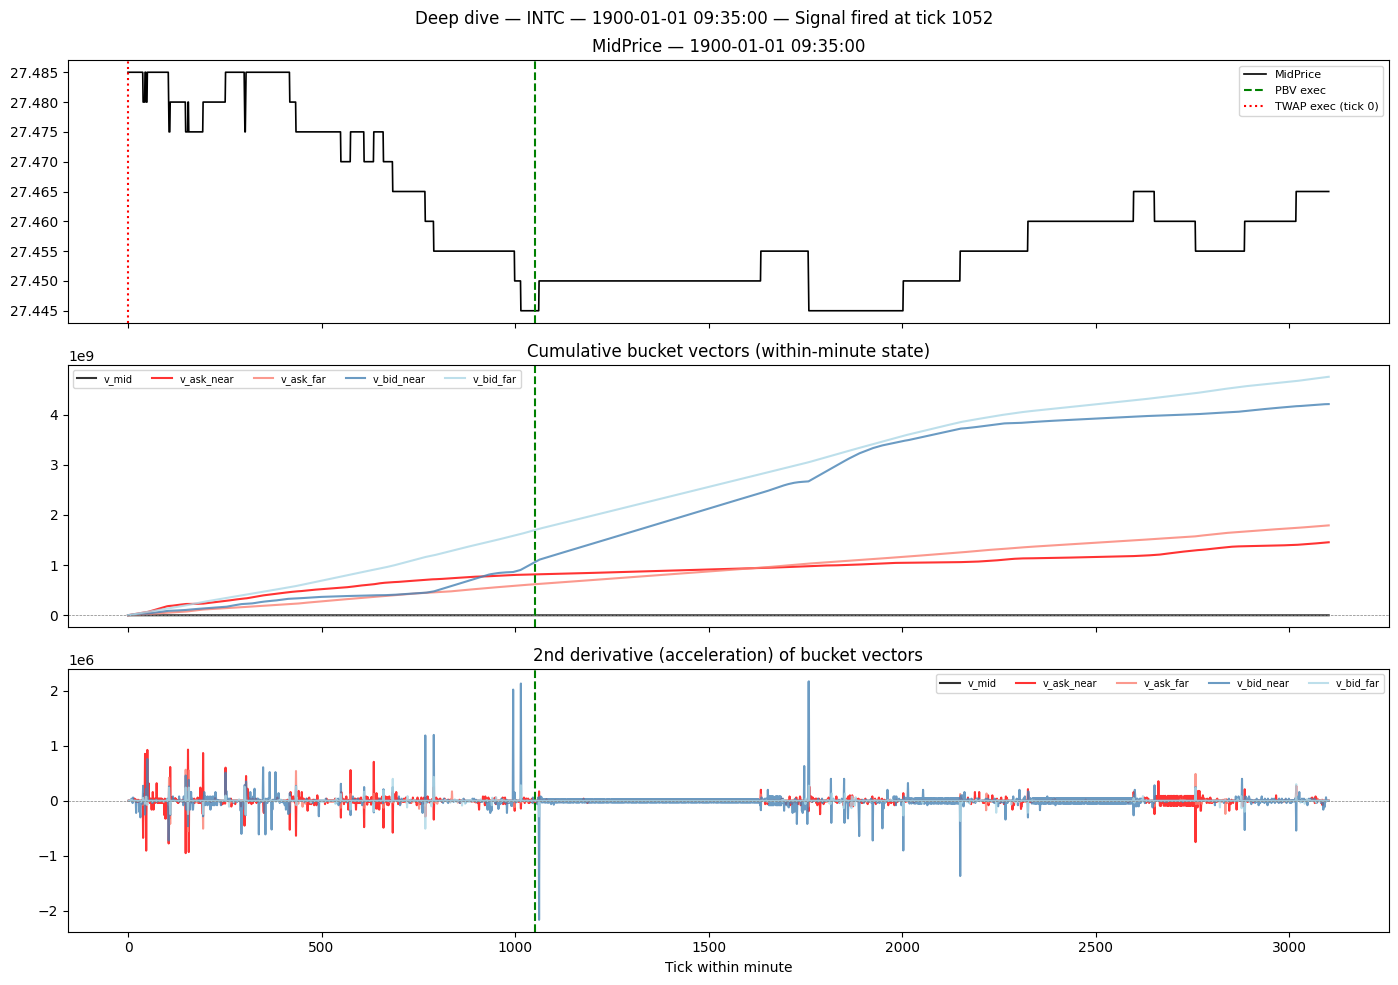

TWAP price : 27.4900
PBV price  : 27.4500
Improvement: 0.0400


In [9]:
# ============================================================
# CELL 8: Single-Minute Deep Dive — Signal Overlay
# ============================================================
# Visualise one minute in detail: bucket vectors + 2nd derivatives + where signal fired.

INSPECT_MINUTE_IDX = 5   # change to inspect a different minute
inspect_minute = train["Minute"].unique()[INSPECT_MINUTE_IDX]
sample = train[train["Minute"] == inspect_minute].reset_index(drop=True)
sample["signal"] = sample.apply(SIGNAL_FN, axis=1)

fired_idx = sample[sample["signal"]].index[0] if sample["signal"].any() else len(sample) - 1

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Mid price
axes[0].plot(sample["MidPrice"].values, color="black", linewidth=1.2, label="MidPrice")
axes[0].axvline(fired_idx, color="green", linestyle="--", linewidth=1.5, label="PBV exec")
axes[0].axvline(0, color="red", linestyle=":", linewidth=1.5, label="TWAP exec (tick 0)")
axes[0].set_title(f"MidPrice — {inspect_minute}")
axes[0].legend(fontsize=8)

# Cumulative bucket vectors
colors = ["black", "red", "salmon", "steelblue", "lightblue"]
for col, c in zip(BUCKET_COLS, colors):
    axes[1].plot(sample[f"{col}_cum"].values, label=col, color=c, alpha=0.8)
axes[1].axvline(fired_idx, color="green", linestyle="--", linewidth=1.5)
axes[1].axhline(0, color="gray", linewidth=0.5, linestyle="--")
axes[1].set_title("Cumulative bucket vectors (within-minute state)")
axes[1].legend(fontsize=7, ncol=5)

# 2nd derivatives
for col, c in zip(BUCKET_COLS, colors):
    axes[2].plot(sample[f"{col}_d2"].values, label=col, color=c, alpha=0.8)
axes[2].axvline(fired_idx, color="green", linestyle="--", linewidth=1.5)
axes[2].axhline(0, color="gray", linewidth=0.5, linestyle="--")
axes[2].set_title("2nd derivative (acceleration) of bucket vectors")
axes[2].set_xlabel("Tick within minute")
axes[2].legend(fontsize=7, ncol=5)

plt.suptitle(f"Deep dive — {STOCK} — {inspect_minute} — Signal fired at tick {fired_idx}", fontsize=12)
plt.tight_layout()
plt.show()

print(f"TWAP price : {sample.iloc[0][EXEC_PRICE_COL]:.4f}")
print(f"PBV price  : {sample.iloc[fired_idx][EXEC_PRICE_COL]:.4f}")
print(f"Improvement: {(sample.iloc[0][EXEC_PRICE_COL] - sample.iloc[fired_idx][EXEC_PRICE_COL]):.4f}")

## Next Steps

### Signal Refinement
- **Threshold tuning**: replace hard-coded `< 0` comparisons with adaptive thresholds (e.g. rolling percentile of d2 within the minute so far)
- **Far bucket signals**: add `v_ask_far_d2` and `v_bid_far_d2` — outer book acceleration often leads inner book moves
- **Combined score**: weighted sum of all 5 bucket signals into a single scalar, then threshold that
- **Minimum hold period**: require N consecutive signal ticks before executing (noise filter)

### Feature Extensions
- **Spread interaction**: down-weight signal when spread is wide (execution more costly)
- **Trade flow**: incorporate `Direction_1=Buy_-1=Sell` to separate passive vs aggressive activity per bucket
- **Cross-level momentum**: slope of `v_ask_near_cum` vs `v_ask_far_cum` — divergence often precedes price move

### Scaling to All Stocks
- Set `STOCK = "GOOG"` / `"INTC"` / `"MSFT"` in Cell 1 and re-run
- Wrap everything in a loop over stocks and collect per-stock improvement stats
- Stock-specific signal calibration may be needed (INTC has very different tick size / liquidity profile)

### Evaluation
- Run on **out-of-sample test data** once strategy is tuned on train
- Report: mean improvement per share, % minutes beating TWAP, per-stock breakdown

## Composite Pressure-Bucket d2 Strategy

Extension of the base PBV signal: instead of watching only `v_ask_near_d2`, build a **weighted composite** across near + far pressure buckets (`W_NEAR=0.7`, `W_FAR=0.3`), apply an adaptive expanding-percentile threshold within each minute, and require 2 consecutive confirming ticks before firing. The `v_mid_cum > 0` condition from the base strategy is retained — this is the key improvement over pbv_v2 which used raw sizes with no imbalance term.

In [10]:
# ============================================================
# CELL 10: Composite Pressure-Bucket d2 Scores
# ============================================================
W_NEAR = 0.7
W_FAR  = 0.3

train["elapsed"]   = (train["Time_dt"] - train["Minute"]).dt.total_seconds()
train["ask_score"] = W_NEAR * train["v_ask_near_d2"] + W_FAR * train["v_ask_far_d2"]
train["bid_score"] = W_NEAR * train["v_bid_near_d2"] + W_FAR * train["v_bid_far_d2"]

print("Composite score summary:")
print(train[["ask_score", "bid_score"]].describe().round(5))

Composite score summary:
          ask_score     bid_score
count  4.301780e+05  4.301780e+05
mean   5.922670e+00  3.867010e+00
std    8.599631e+04  1.036335e+05
min   -1.003828e+07 -9.112460e+06
25%   -0.000000e+00 -1.200000e+03
50%    0.000000e+00  0.000000e+00
75%    0.000000e+00  0.000000e+00
max    1.003828e+07  9.112460e+06


In [11]:
# ============================================================
# CELL 11: Adaptive Expanding-Percentile Threshold
# ============================================================
PERCENTILE_N = 40

train["abs_composite"] = (train["ask_score"].abs() + train["bid_score"].abs()) / 2.0

def expanding_percentile(s, q):
    arr = s.values.astype(float)
    out = np.empty(len(arr))
    for k in range(len(arr)):
        valid = arr[:k+1][~np.isnan(arr[:k+1])]
        out[k] = np.nanpercentile(valid, q) if len(valid) else np.nan
    return pd.Series(out, index=s.index)

train["adaptive_thresh"] = (
    train.groupby("Minute")["abs_composite"]
    .transform(lambda s: expanding_percentile(s, PERCENTILE_N))
)
train["adaptive_thresh"] = train["adaptive_thresh"].fillna(train["abs_composite"].median())

print(f"Adaptive threshold stats (percentile={PERCENTILE_N}):")
print(train["adaptive_thresh"].describe().round(5))

Adaptive threshold stats (percentile=40):
count    430718.00000
mean       6776.59542
std        4294.83081
min           0.00000
25%        5000.00000
50%        7000.00000
75%        7000.00000
max      357000.00000
Name: adaptive_thresh, dtype: float64


In [12]:
# ============================================================
# CELL 12: Composite Signal + Consecutive-Tick Confirmation
# ============================================================
if SIDE == "BUY":
    train["raw_signal_comp"] = (
        (train["ask_score"] < -train["adaptive_thresh"]) &
        (train["bid_score"] >  train["adaptive_thresh"]) &
        (train["v_mid_cum"] >  0)
    ).fillna(False)
else:
    train["raw_signal_comp"] = (
        (train["bid_score"] < -train["adaptive_thresh"]) &
        (train["ask_score"] >  train["adaptive_thresh"]) &
        (train["v_mid_cum"] <  0)
    ).fillna(False)

train["prev_raw_comp"] = train.groupby("Minute")["raw_signal_comp"].shift(1).fillna(False)
train["consec_comp"]   = train["raw_signal_comp"] & train["prev_raw_comp"]
train["signal_comp"]   = train["consec_comp"] | (train["elapsed"] >= FALLBACK_SECONDS)

print(f"Consecutive signal fires on {train['consec_comp'].sum()} rows ({100*train['consec_comp'].mean():.2f}% of ticks)")
print(f"With fallback: {train['signal_comp'].sum()} rows ({100*train['signal_comp'].mean():.2f}% of ticks)")

# ============================================================
# Build base signal on train so simulate() can access it.
# Logic mirrors buy_signal / sell_signal from Cell 5 but
# applied vectorised across the full DataFrame.
# ============================================================
if SIDE == "BUY":
    train["signal"] = (
        (train["v_ask_near_d2"] < 0) &
        (train["v_mid_cum"]     > 0)
    ).fillna(False) | (train["elapsed"] >= FALLBACK_SECONDS)
else:
    train["signal"] = (
        (train["v_bid_near_d2"] < 0) &
        (train["v_mid_cum"]     < 0)
    ).fillna(False) | (train["elapsed"] >= FALLBACK_SECONDS)

print(f"Base signal fires on {train['signal'].sum()} rows ({100*train['signal'].mean():.2f}% of ticks)")

Consecutive signal fires on 27 rows (0.01% of ticks)
With fallback: 72592 rows (16.85% of ticks)
Base signal fires on 132787 rows (30.83% of ticks)


In [13]:
# ============================================================
# CELL 13: Simulation & Comparison — Base vs Composite PBV
# ============================================================
twap_series = train.groupby("Minute")[EXEC_PRICE_COL].first().rename("twap_price")

def simulate(signal_col, label):
    first_idx = train[train[signal_col]].groupby("Minute").apply(lambda g: g.index[0])
    exec_rows = train.loc[first_idx, ["Minute", EXEC_PRICE_COL, "elapsed"]].copy()
    exec_rows.columns = ["Minute", "pbv_price", "exec_second"]
    exec_rows = exec_rows.set_index("Minute")
    res = twap_series.to_frame().join(exec_rows)
    res["fallback"]    = res["exec_second"] >= FALLBACK_SECONDS
    res["improvement"] = (res["twap_price"] - res["pbv_price"]) if SIDE == "BUY" else (res["pbv_price"] - res["twap_price"])
    res["label"] = label
    return res

results_base = simulate("signal",      "Base PBV (near d2 + v_mid_cum)")
results_comp = simulate("signal_comp", "Composite PBV (near+far d2 + v_mid_cum)")

def print_summary(res, label):
    _nf = res[~res["fallback"]]
    print(f"\n{'='*58}\n  {label}")
    print(f"  Minutes          : {len(res)}")
    print(f"  Fallback         : {res['fallback'].sum()} ({100*res['fallback'].mean():.1f}%)")
    print(f"  Mean improvement : ${res['improvement'].mean():.5f}")
    print(f"  Median improv.   : ${res['improvement'].median():.5f}")
    print(f"  % beating TWAP   : {100*(res['improvement'] > 0).mean():.1f}%")
    print(f"  % non-fb beating : {100*(_nf['improvement'] > 0).mean():.1f}%  (n={len(_nf)})")
    print(f"  Mean exec second : {res['exec_second'].mean():.1f}s")

print_summary(results_base, f"Base PBV — {STOCK} — BASELINE")
print_summary(results_comp, f"Composite PBV — {STOCK} — NEW")


  Base PBV — INTC — BASELINE
  Minutes          : 270
  Fallback         : 57 (21.1%)
  Mean improvement : $0.00237
  Median improv.   : $0.00000
  % beating TWAP   : 17.0%
  % non-fb beating : 6.1%  (n=213)
  Mean exec second : 15.4s

  Composite PBV — INTC — NEW
  Minutes          : 270
  Fallback         : 257 (95.2%)
  Mean improvement : $0.00230
  Median improv.   : $0.00000
  % beating TWAP   : 33.3%
  % non-fb beating : 53.8%  (n=13)
  Mean exec second : 49.1s


/tmp/ipykernel_2863/1032292906.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


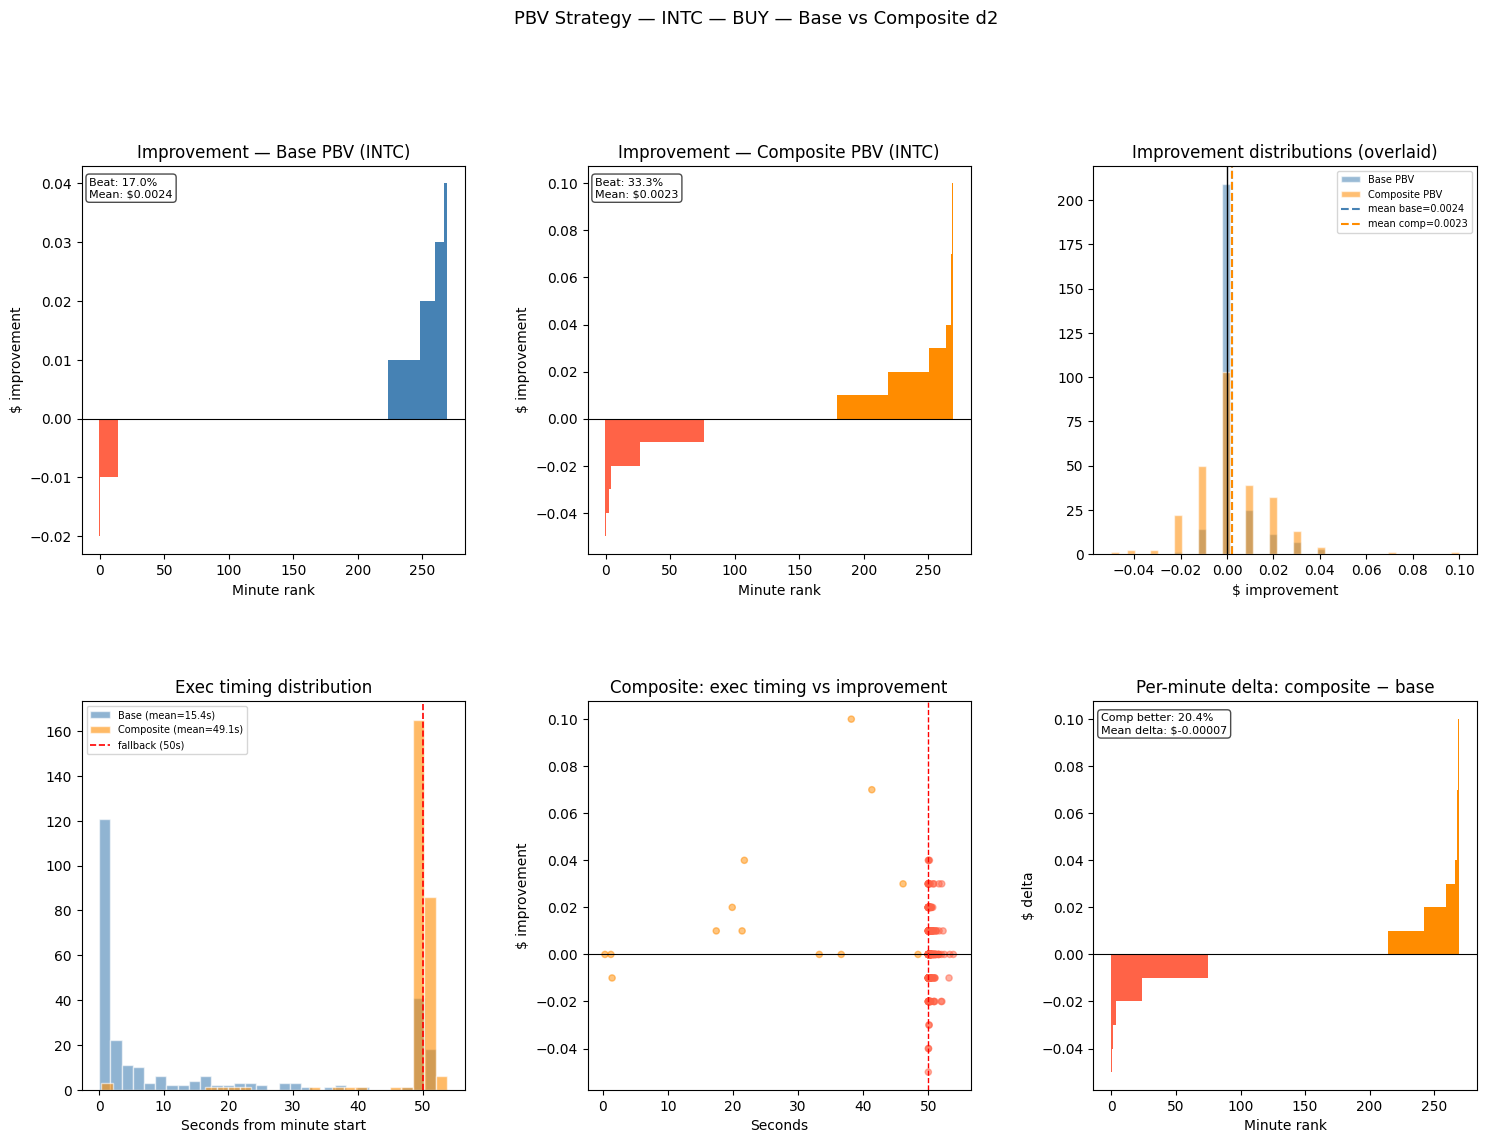

In [14]:
# ============================================================
# CELL 14: Visualisation — Composite vs Base PBV
# ============================================================
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)
ax_bar_old = fig.add_subplot(gs[0, 0]); ax_bar_new = fig.add_subplot(gs[0, 1])
ax_dist    = fig.add_subplot(gs[0, 2]); ax_timing  = fig.add_subplot(gs[1, 0])
ax_scatter = fig.add_subplot(gs[1, 1]); ax_delta   = fig.add_subplot(gs[1, 2])

for ax, res, title, clr in [
    (ax_bar_old, results_base, f"Improvement — Base PBV ({STOCK})",      "steelblue"),
    (ax_bar_new, results_comp, f"Improvement — Composite PBV ({STOCK})", "darkorange"),
]:
    s = res["improvement"].sort_values()
    ax.bar(range(len(s)), s.values, color=[clr if v >= 0 else "tomato" for v in s.values], width=1.0, edgecolor="none")
    ax.axhline(0, color="black", lw=0.8); ax.set(title=title, xlabel="Minute rank", ylabel="$ improvement")
    ax.text(0.02, 0.97, f"Beat: {100*(res['improvement']>0).mean():.1f}%\nMean: ${res['improvement'].mean():.4f}",
            transform=ax.transAxes, va="top", fontsize=8, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

bins = np.linspace(min(results_base["improvement"].min(), results_comp["improvement"].min()),
                   max(results_base["improvement"].max(), results_comp["improvement"].max()), 45)
ax_dist.hist(results_base["improvement"], bins=bins, alpha=0.55, color="steelblue",  label="Base PBV",      edgecolor="white")
ax_dist.hist(results_comp["improvement"], bins=bins, alpha=0.55, color="darkorange", label="Composite PBV", edgecolor="white")
ax_dist.axvline(0, color="black", lw=1)
ax_dist.axvline(results_base["improvement"].mean(), color="steelblue",  lw=1.5, ls="--", label=f"mean base={results_base['improvement'].mean():.4f}")
ax_dist.axvline(results_comp["improvement"].mean(), color="darkorange", lw=1.5, ls="--", label=f"mean comp={results_comp['improvement'].mean():.4f}")
ax_dist.set(title="Improvement distributions (overlaid)", xlabel="$ improvement"); ax_dist.legend(fontsize=7)

ax_timing.hist(results_base["exec_second"], bins=30, alpha=0.6, color="steelblue",  label=f"Base (mean={results_base['exec_second'].mean():.1f}s)", edgecolor="white")
ax_timing.hist(results_comp["exec_second"], bins=30, alpha=0.6, color="darkorange", label=f"Composite (mean={results_comp['exec_second'].mean():.1f}s)", edgecolor="white")
ax_timing.axvline(FALLBACK_SECONDS, color="red", lw=1.2, ls="--", label=f"fallback ({FALLBACK_SECONDS}s)")
ax_timing.set(title="Exec timing distribution", xlabel="Seconds from minute start"); ax_timing.legend(fontsize=7)

ax_scatter.scatter(results_comp["exec_second"], results_comp["improvement"],
                   c=results_comp["fallback"].map({True: "tomato", False: "darkorange"}), alpha=0.5, s=20)
ax_scatter.axhline(0, color="black", lw=0.8); ax_scatter.axvline(FALLBACK_SECONDS, color="red", lw=1, ls="--")
ax_scatter.set(title="Composite: exec timing vs improvement", xlabel="Seconds", ylabel="$ improvement")

delta = results_comp["improvement"] - results_base["improvement"]
delta_s = delta.sort_values()
ax_delta.bar(range(len(delta_s)), delta_s.values, color=["darkorange" if v >= 0 else "tomato" for v in delta_s.values], width=1.0, edgecolor="none")
ax_delta.axhline(0, color="black", lw=0.8); ax_delta.set(title="Per-minute delta: composite − base", xlabel="Minute rank", ylabel="$ delta")
ax_delta.text(0.02, 0.97, f"Comp better: {100*(delta>0).mean():.1f}%\nMean delta: ${delta.mean():.5f}",
              transform=ax_delta.transAxes, va="top", fontsize=8, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

plt.suptitle(f"PBV Strategy — {STOCK} — {SIDE} — Base vs Composite d2", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

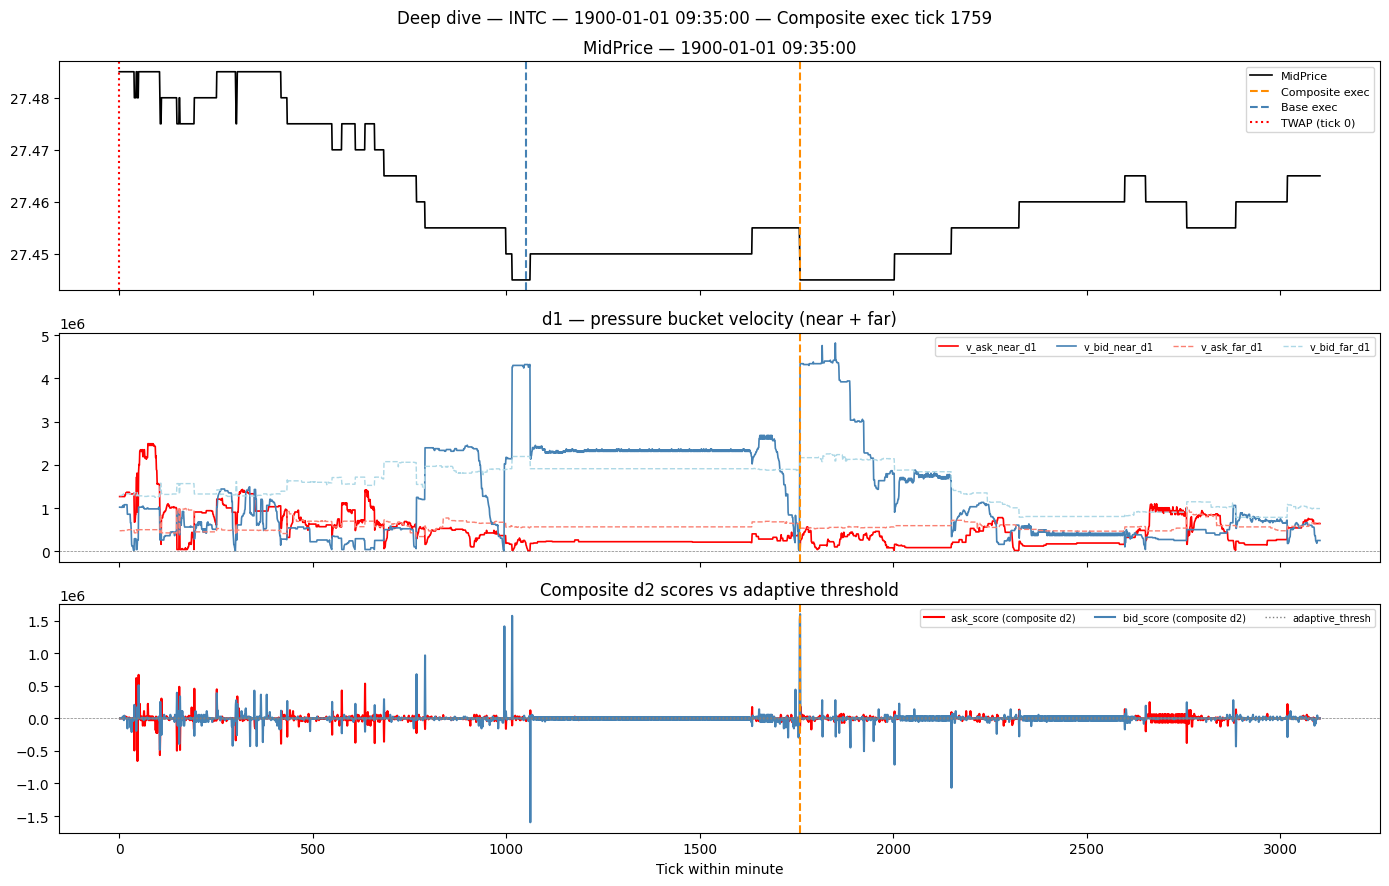

TWAP      : 27.4900
Base PBV  : 27.4500  improvement: 0.0400
Composite : 27.4500  improvement: 0.0400


In [15]:
# ============================================================
# CELL 15: Single-Minute Deep Dive — Composite Signal Overlay
# ============================================================
INSPECT_IDX    = 5
inspect_minute = train["Minute"].unique()[INSPECT_IDX]
samp           = train[train["Minute"] == inspect_minute].reset_index(drop=True)
samp["signal"] = samp.apply(SIGNAL_FN, axis=1)
samp["sig_comp"] = (
    (samp["ask_score"] < -samp["adaptive_thresh"]) &
    (samp["bid_score"] >  samp["adaptive_thresh"]) &
    (samp["v_mid_cum"] >  0)
).fillna(False)
samp["prev_sig"] = samp["sig_comp"].shift(1).fillna(False)
samp["full_sig"] = (samp["sig_comp"] & samp["prev_sig"]) | (samp["elapsed"] >= FALLBACK_SECONDS)

base_idx = samp[samp["signal"]].index[0]    if samp["signal"].any()   else len(samp) - 1
comp_idx = samp[samp["full_sig"]].index[0]  if samp["full_sig"].any() else len(samp) - 1

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(samp["MidPrice"].values, color="black", lw=1.2, label="MidPrice")
axes[0].axvline(comp_idx, color="darkorange", ls="--", lw=1.5, label="Composite exec")
axes[0].axvline(base_idx, color="steelblue",  ls="--", lw=1.5, label="Base exec")
axes[0].axvline(0, color="red", ls=":", lw=1.5, label="TWAP (tick 0)")
axes[0].set_title(f"MidPrice — {inspect_minute}"); axes[0].legend(fontsize=8)

axes[1].plot(samp["v_ask_near_d1"].values, color="red",       lw=1.2, label="v_ask_near_d1")
axes[1].plot(samp["v_bid_near_d1"].values, color="steelblue", lw=1.2, label="v_bid_near_d1")
axes[1].plot(samp["v_ask_far_d1"].values,  color="salmon",    lw=1.0, ls="--", label="v_ask_far_d1")
axes[1].plot(samp["v_bid_far_d1"].values,  color="lightblue", lw=1.0, ls="--", label="v_bid_far_d1")
axes[1].axvline(comp_idx, color="darkorange", ls="--", lw=1.5)
axes[1].axhline(0, color="gray", lw=0.5, ls="--")
axes[1].set_title("d1 — pressure bucket velocity (near + far)"); axes[1].legend(fontsize=7, ncol=4)

axes[2].plot(samp["ask_score"].values,        color="red",       lw=1.5, label="ask_score (composite d2)")
axes[2].plot(samp["bid_score"].values,        color="steelblue", lw=1.5, label="bid_score (composite d2)")
axes[2].plot( samp["adaptive_thresh"].values, color="gray",      lw=1.0, ls=":", label="adaptive_thresh")
axes[2].plot(-samp["adaptive_thresh"].values, color="gray",      lw=1.0, ls=":")
axes[2].axvline(comp_idx, color="darkorange", ls="--", lw=1.5)
axes[2].axhline(0, color="gray", lw=0.5, ls="--")
axes[2].set_title("Composite d2 scores vs adaptive threshold")
axes[2].set_xlabel("Tick within minute"); axes[2].legend(fontsize=7, ncol=3)

plt.suptitle(f"Deep dive — {STOCK} — {inspect_minute} — Composite exec tick {comp_idx}", fontsize=12)
plt.tight_layout(); plt.show()

twap_p = samp.iloc[0][EXEC_PRICE_COL]
base_p = samp.iloc[base_idx][EXEC_PRICE_COL]
comp_p = samp.iloc[comp_idx][EXEC_PRICE_COL]
print(f"TWAP      : {twap_p:.4f}")
print(f"Base PBV  : {base_p:.4f}  improvement: {twap_p - base_p:.4f}")
print(f"Composite : {comp_p:.4f}  improvement: {twap_p - comp_p:.4f}")

Running cross-stock pipeline...
Done.

  Cross-stock summary — BUY side
       Minutes Base mean $ Base beat % Base exec s Comp mean $ Comp beat % Comp exec s
Stock                                                                                 
AMZN       270     0.00719        26.3         9.8     0.00611        52.2        40.6
GOOG       270     0.01063        35.6        16.0     0.02770        53.3        47.6
INTC       270     0.00237        17.0        15.4     0.00230        33.3        49.1
MSFT       270     0.00300        18.9        17.5     0.00144        35.9        49.6


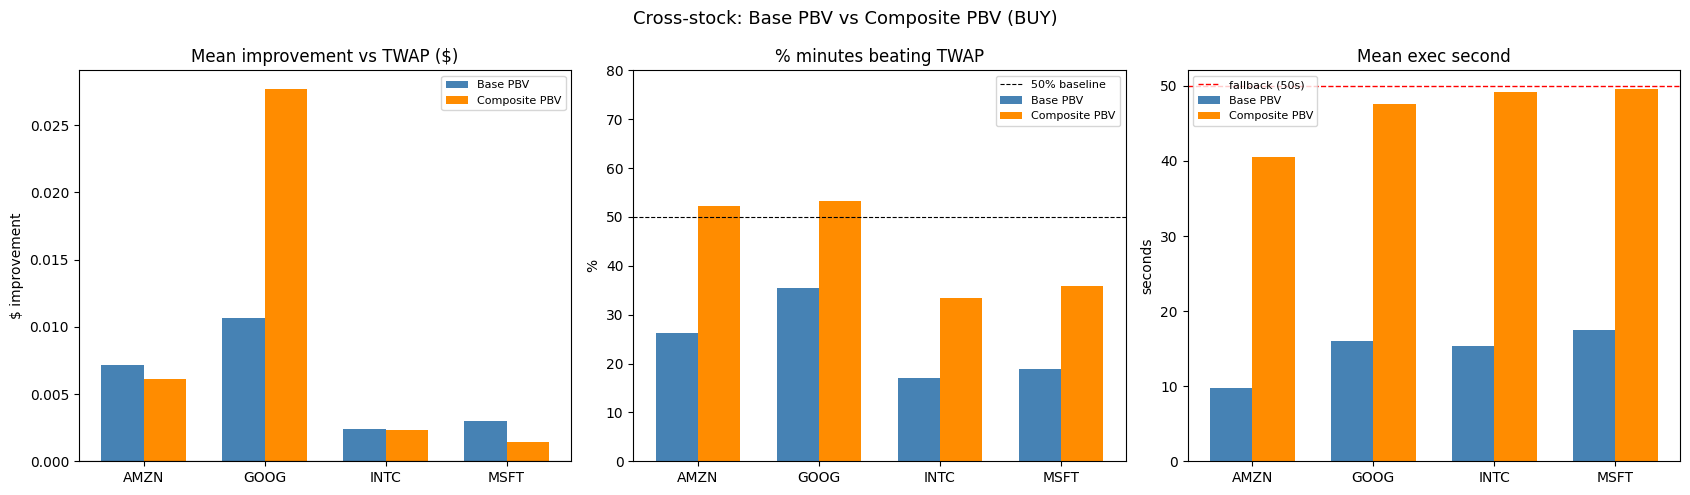

In [16]:
# ============================================================
# CELL 16: Cross-Stock Evaluation — Base PBV vs Composite PBV
# ============================================================
STOCKS_ALL = ["AMZN", "GOOG", "INTC", "MSFT"]

def run_stock_full(stock):
    d = pd.read_csv(f"training_datasets/{stock}_5levels_train.csv")
    d["Time_dt"] = pd.to_datetime(d["Time"], format="%H:%M:%S.%f")
    d["Minute"]  = d["Time_dt"].dt.floor("min")
    d["elapsed"] = (d["Time_dt"] - d["Minute"]).dt.total_seconds()

    mid = d["MidPrice"]
    b1, a1 = d["BidSize_1"], d["AskSize_1"]
    d["v_mid"]      = (b1 - a1) / (b1 + a1 + EPS)
    d["v_ask_near"] = d["AskSize_1"] / (d["AskPrice_1"] - mid).clip(lower=EPS)
    d["v_ask_far"]  = sum(d[f"AskSize_{i}"] / (d[f"AskPrice_{i}"] - mid).clip(lower=EPS) for i in range(2, 6))
    d["v_bid_near"] = d["BidSize_1"] / (mid - d["BidPrice_1"]).clip(lower=EPS)
    d["v_bid_far"]  = sum(d[f"BidSize_{i}"] / (mid - d[f"BidPrice_{i}"]).clip(lower=EPS) for i in range(2, 6))

    _BCOLS = ["v_mid", "v_ask_near", "v_ask_far", "v_bid_near", "v_bid_far"]
    grp = d.groupby("Minute")
    for col in _BCOLS:
        d[f"{col}_cum"] = grp[col].cumsum()
        d[f"{col}_d1"]  = grp[f"{col}_cum"].diff()
        d[f"{col}_d2"]  = grp[f"{col}_d1"].diff()

    d["signal_base"] = (
        (d["v_ask_near_d2"] < 0) & (d["v_mid_cum"] > 0)
    ).fillna(False) | (d["elapsed"] >= FALLBACK_SECONDS)

    d["ask_score_s"] = W_NEAR * d["v_ask_near_d2"] + W_FAR * d["v_ask_far_d2"]
    d["bid_score_s"] = W_NEAR * d["v_bid_near_d2"] + W_FAR * d["v_bid_far_d2"]
    d["abs_comp_s"]  = (d["ask_score_s"].abs() + d["bid_score_s"].abs()) / 2.0
    d["thresh_s"]    = d.groupby("Minute")["abs_comp_s"].transform(
        lambda s: expanding_percentile(s, PERCENTILE_N)
    )
    d["thresh_s"]    = d["thresh_s"].fillna(d["abs_comp_s"].median())
    d["raw_comp_s"]  = (
        (d["ask_score_s"] < -d["thresh_s"]) &
        (d["bid_score_s"] >  d["thresh_s"]) &
        (d["v_mid_cum"]   >  0)
    ).fillna(False)
    d["prev_comp_s"]   = d.groupby("Minute")["raw_comp_s"].shift(1).fillna(False)
    d["signal_comp_s"] = (d["raw_comp_s"] & d["prev_comp_s"]) | (d["elapsed"] >= FALLBACK_SECONDS)

    twap_s = d.groupby("Minute")["AskPrice_1"].first().rename("twap_price")

    def _sim(sig_col):
        fi  = d[d[sig_col]].groupby("Minute").apply(lambda g: g.index[0])
        er  = d.loc[fi, ["Minute", "AskPrice_1", "elapsed"]].copy()
        er.columns = ["Minute", "pbv_price", "exec_second"]
        er  = er.set_index("Minute")
        res = twap_s.to_frame().join(er)
        res["fallback"]    = res["exec_second"] >= FALLBACK_SECONDS
        res["improvement"] = res["twap_price"] - res["pbv_price"]
        return res

    r_base = _sim("signal_base")
    r_comp = _sim("signal_comp_s")
    return {
        "stock": stock, "minutes": len(r_base),
        "base_mean": r_base["improvement"].mean(), "base_beat": (r_base["improvement"] > 0).mean() * 100,
        "base_exec": r_base["exec_second"].mean(),
        "comp_mean": r_comp["improvement"].mean(), "comp_beat": (r_comp["improvement"] > 0).mean() * 100,
        "comp_exec": r_comp["exec_second"].mean(),
        "r_base": r_base, "r_comp": r_comp,
    }

print("Running cross-stock pipeline...")
stock_res = {s: run_stock_full(s) for s in STOCKS_ALL}
print("Done.")

rows = []
for s, r in stock_res.items():
    rows.append({"Stock": s, "Minutes": r["minutes"],
        "Base mean $": f"{r['base_mean']:.5f}", "Base beat %": f"{r['base_beat']:.1f}", "Base exec s": f"{r['base_exec']:.1f}",
        "Comp mean $": f"{r['comp_mean']:.5f}", "Comp beat %": f"{r['comp_beat']:.1f}", "Comp exec s": f"{r['comp_exec']:.1f}"})

summary_xs = pd.DataFrame(rows).set_index("Stock")
print("\n" + "="*70 + "\n  Cross-stock summary — BUY side\n" + "="*70)
print(summary_xs.to_string())

x, width = np.arange(len(STOCKS_ALL)), 0.35
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
axes[0].bar(x - width/2, [stock_res[s]["base_mean"] for s in STOCKS_ALL], width, label="Base PBV",      color="steelblue")
axes[0].bar(x + width/2, [stock_res[s]["comp_mean"] for s in STOCKS_ALL], width, label="Composite PBV", color="darkorange")
axes[0].axhline(0, color="black", lw=0.8); axes[0].set_xticks(x); axes[0].set_xticklabels(STOCKS_ALL)
axes[0].set(title="Mean improvement vs TWAP ($)", ylabel="$ improvement"); axes[0].legend(fontsize=8)

axes[1].bar(x - width/2, [stock_res[s]["base_beat"] for s in STOCKS_ALL], width, label="Base PBV",      color="steelblue")
axes[1].bar(x + width/2, [stock_res[s]["comp_beat"] for s in STOCKS_ALL], width, label="Composite PBV", color="darkorange")
axes[1].axhline(50, color="black", lw=0.8, ls="--", label="50% baseline")
axes[1].set_xticks(x); axes[1].set_xticklabels(STOCKS_ALL); axes[1].set(title="% minutes beating TWAP", ylabel="%", ylim=(0, 80)); axes[1].legend(fontsize=8)

axes[2].bar(x - width/2, [stock_res[s]["base_exec"] for s in STOCKS_ALL], width, label="Base PBV",      color="steelblue")
axes[2].bar(x + width/2, [stock_res[s]["comp_exec"] for s in STOCKS_ALL], width, label="Composite PBV", color="darkorange")
axes[2].axhline(FALLBACK_SECONDS, color="red", lw=1, ls="--", label=f"fallback ({FALLBACK_SECONDS}s)")
axes[2].set_xticks(x); axes[2].set_xticklabels(STOCKS_ALL); axes[2].set(title="Mean exec second", ylabel="seconds"); axes[2].legend(fontsize=8)

plt.suptitle("Cross-stock: Base PBV vs Composite PBV (BUY)", fontsize=13)
plt.tight_layout(); plt.show()